## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 3
#### ***Part C: Autoencoder - Digit Addition Reconstruction***

This notebook implements autoencoders that learn to add two MNIST digits.

In [2]:
import numpy as np
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import dataProccessing as dp
import digitAdder as da
from keras import layers, Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

**MNIST dataset preparation**

In [3]:
# Load MNIST
x_train, y_train, x_test, y_test = dp.load_mnist()

# Create digit addition dataset
train_inputs, train_outputs, train_sums = da.create_digit_adder_dataset(x_train, y_train, seed=42)

test_inputs, test_outputs, test_sums = da.create_digit_adder_dataset(x_test, y_test, seed=123)

# For convolutional models: (N, 28, 56, 1)
train_inputs_cnn = train_inputs.reshape(-1, 28, 56, 1)
train_outputs_cnn = train_outputs.reshape(-1, 28, 56, 1)
test_inputs_cnn = test_inputs.reshape(-1, 28, 56, 1)
test_outputs_cnn = test_outputs.reshape(-1, 28, 56, 1)

# For dense models: (N, 28*56)
train_inputs_flat = train_inputs.reshape(-1, 28*56)
train_outputs_flat = train_outputs.reshape(-1, 28*56)
test_inputs_flat = test_inputs.reshape(-1, 28*56)
test_outputs_flat = test_outputs.reshape(-1, 28*56)

Loading and Normalizing MNIST Dataset
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Creating digit addition pairs...
0 + 0 = 0 (0,0): 100 pairs
0 + 1 = 1 (0,1): 100 pairs
0 + 2 = 2 (0,2): 100 pairs
0 + 3 = 3 (0,3): 100 pairs
0 + 4 = 4 (0,4): 100 pairs
0 + 5 = 5 (0,5): 100 pairs
0 + 6 = 6 (0,6): 100 pairs
0 + 7 = 7 (0,7): 100 pairs
0 + 8 = 8 (0,8): 100 pairs
0 + 9 = 9 (0,9): 100 pairs
1 + 0 = 1 (0,1): 100 pairs
1 + 1 = 2 (0,2): 100 pairs
1 + 2 = 3 (0,3): 100 pairs
1 + 3 = 4 (0,4): 100 pairs
1 + 4 = 5 (0,5): 100 pairs
1 + 5 = 6 (0,6): 100 pairs
1 + 6 = 7 (0,7): 100 pairs
1 + 7 = 8 (0,8): 100 pairs
1 + 8 = 9 (0,9): 100 pairs
1 + 9 = 10 (1,0): 100 pairs
2 + 0 = 2 (0,2): 100 pairs
2 + 1 = 3 (0,3): 100 pairs
2 + 2 = 4 (0,4): 100 pairs
2 + 3 = 5 (0,5): 100 pairs
2 + 4 = 6 (0,6): 100 pairs
2 + 5 = 7 (0,7): 100 pairs
2 + 6 = 8 (0,8): 100 pairs
2 + 7 = 9 (0,9): 100 pairs
2 + 8 = 10 (1,0): 100 pairs
2 + 9 = 11 (

#### **Model 1: Dense Digit Adder Autoencoder**

No Dropout layers.


Training Digit Addition Model 1...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.1013 - val_loss: 0.0712
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0686 - val_loss: 0.0672
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0667 - val_loss: 0.0658
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0644 - val_loss: 0.0643
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0631 - val_loss: 0.0633
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0620 - val_loss: 0.0629
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0606 - val_loss: 0.0627
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0600 - val_loss: 0.0631
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0591 - val_loss: 0.0621
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0590 - val_loss: 0.0636
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0586 - val_loss: 0.0618
Epoch 12/50
24/24 ━━━━━━━━━

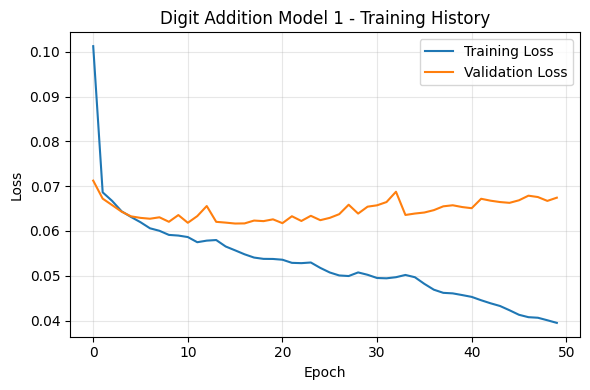

Digit Addition Model 1 Final Validation Loss: 0.067438
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


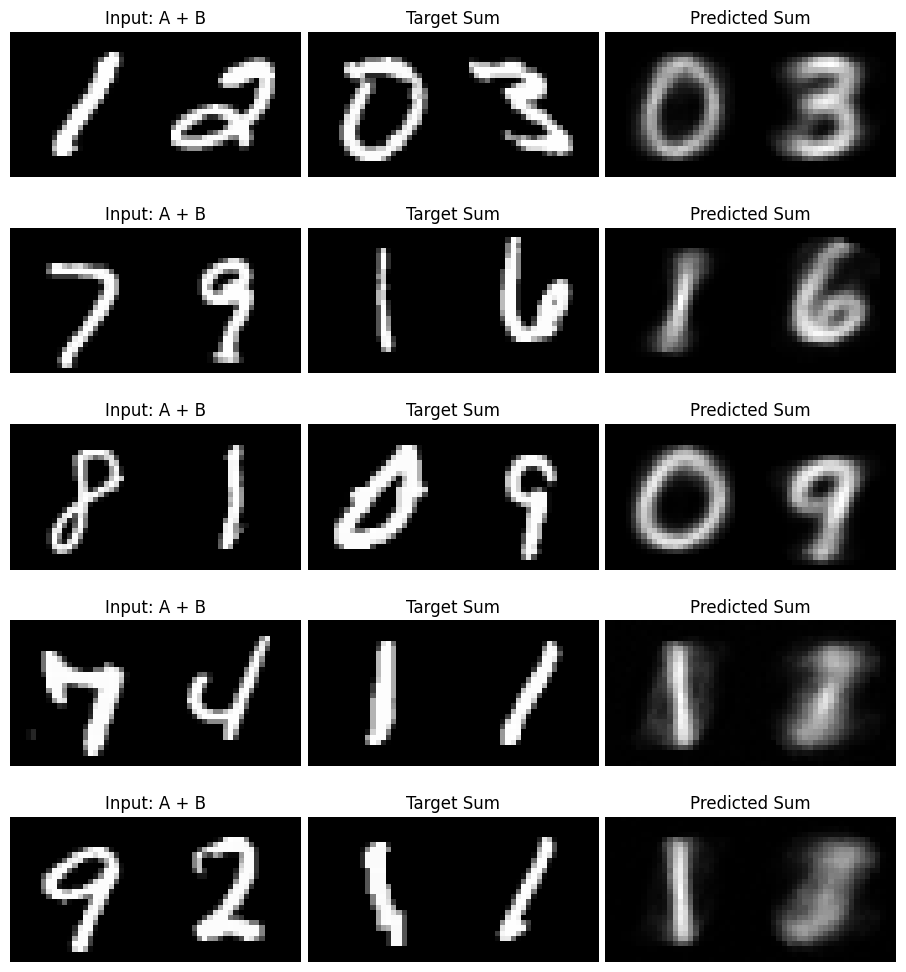

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Digit Addition Model 1 Test MSE: 0.066641


In [4]:
# Model 1: Dense architecture for digit addition
encoding_dim = 256

# Encoder
encoder_input = layers.Input(shape=(28*56,))
x = layers.Dense(1024, activation='relu')(encoder_input)
x = layers.Dense(512, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_da1 = Model(encoder_input, latent, name='encoder_digit_adder1')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(512, activation='relu')(decoder_input)
x = layers.Dense(1024, activation='relu')(x)
decoder_output = layers.Dense(28*56, activation='sigmoid')(x)

decoder_da1 = Model(decoder_input, decoder_output, name='decoder_digit_adder1')

# Digit Addition Autoencoder
autoencoder_da1 = Model(encoder_input, decoder_da1(encoder_da1(encoder_input)), name='autoencoder_digit_adder1')
autoencoder_da1.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Digit Addition Model 1...")
start_time = time.time()
history_da1 = autoencoder_da1.fit(train_inputs_flat, train_outputs_flat, epochs=50,
                                batch_size=256, validation_split=0.4, verbose=1)
train_time_da1 = time.time() - start_time
print(f"Digit Addition Model 1 Training time: {train_time_da1:.2f} seconds")

# Plot history
dp.plot_history(history_da1, 'Digit Addition Model 1')

# Store validation loss
val_loss_da1 = history_da1.history['val_loss'][-1]
print(f"Digit Addition Model 1 Final Validation Loss: {val_loss_da1:.6f}")

# Visualize predictions
predictions_da1 = autoencoder_da1.predict(test_inputs_flat[::10])
da.plot_addition_examples(test_inputs_flat[::10], test_outputs_flat[::10], predictions_da1)

# Evaluate
mse_da1 = dp.calculate_mse(test_outputs_flat, autoencoder_da1.predict(test_inputs_flat))
print(f"Digit Addition Model 1 Test MSE: {mse_da1:.6f}")

#### **Model 2: Deeper Dense Digit Adder Autoencoder**

Added Dropout layers to reduce overfitting. Changed validation split to 0.2 instead of 0.4 and added Early Stopping.


Training Digit Addition Model 2...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - loss: 0.1003 - val_loss: 0.0695
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - loss: 0.0687 - val_loss: 0.0672
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.0671 - val_loss: 0.0654
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.0644 - val_loss: 0.0632
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 0.0626 - val_loss: 0.0625
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - loss: 0.0615 - val_loss: 0.0621
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.0609 - val_loss: 0.0622
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 0.0601 - val_loss: 0.0630
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - loss: 0.0601 - val_loss: 0.0629
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 0.0593 - val_loss: 0.0617
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - loss: 0.0585 - val_loss: 0.0612
Epoch 12/50
32/3

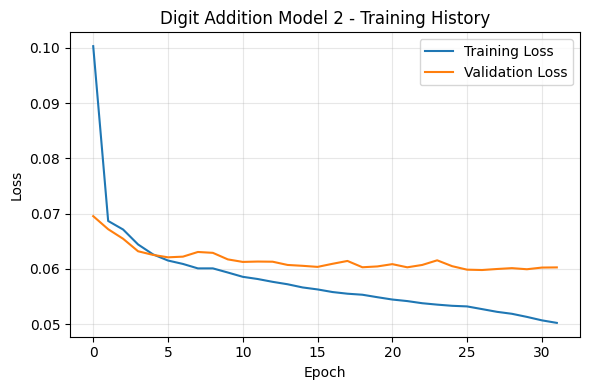

Digit Addition Model 2 Final Validation Loss: 0.060250
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


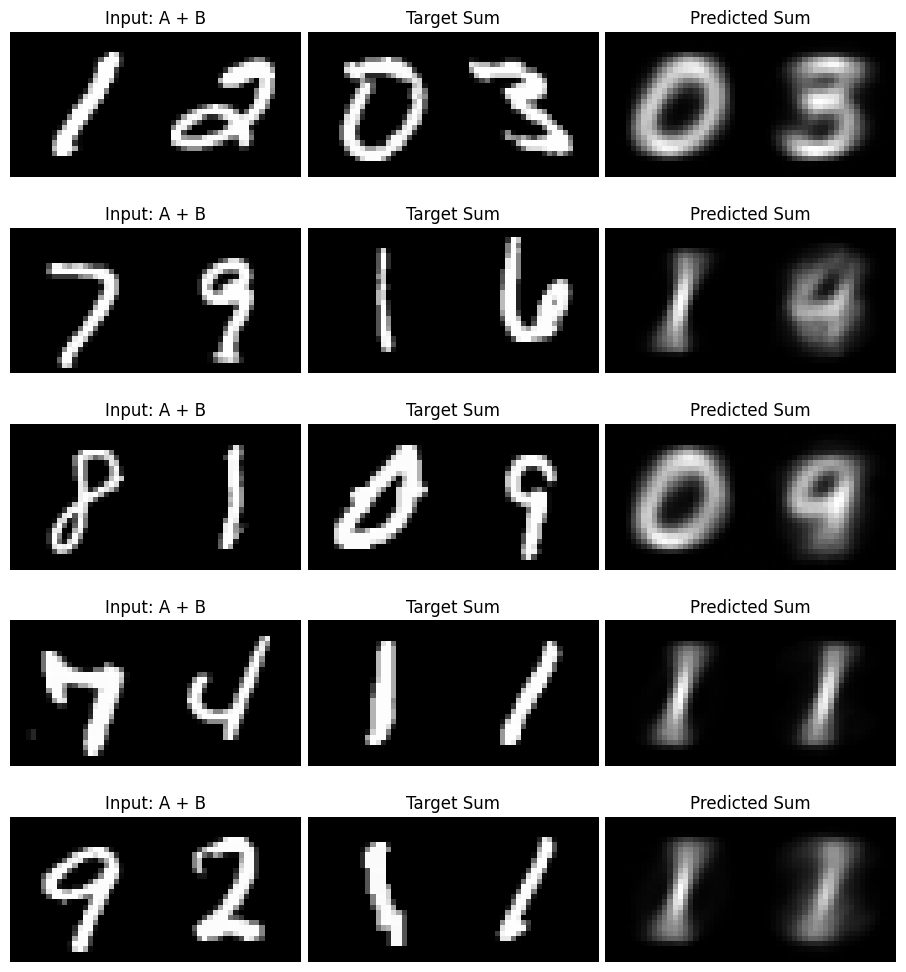

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Digit Addition Model 2 Test MSE: 0.059476


In [5]:
# Model 2: Deeper Dense architecture for digit addition
encoding_dim = 512

# Encoder
encoder_input = layers.Input(shape=(28*56,))
x = layers.Dense(2048, activation='relu')(encoder_input)
x = layers.Dropout(0.3)(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.3)(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_da2 = Model(encoder_input, latent, name='encoder_digit_adder2')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(1024, activation='relu')(decoder_input)
x = layers.Dropout(0.3)(x)
x = layers.Dense(2048, activation='relu')(x)
x = layers.Dropout(0.3)(x)
decoder_output = layers.Dense(28*56, activation='sigmoid')(x)

decoder_da2 = Model(decoder_input, decoder_output, name='decoder_digit_adder2')

# Digit Addition Autoencoder
autoencoder_da2 = Model(encoder_input, decoder_da2(encoder_da2(encoder_input)), name='autoencoder_digit_adder2')
autoencoder_da2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True)

# Train the model
print("\nTraining Digit Addition Model 2...")
start_time = time.time()
history_da2 = autoencoder_da2.fit(train_inputs_flat, train_outputs_flat, epochs=50,
            batch_size=256, validation_split=0.2, callbacks=[early_stop], verbose=1)
train_time_da2 = time.time() - start_time
print(f"Digit Addition Model 2 Training time: {train_time_da2:.2f} seconds")
print(f"Digit Addition Model 2 Stopped at Epoch: {len(history_da2.history['loss'])}")

# Plot history
dp.plot_history(history_da2, 'Digit Addition Model 2')

# Store validation loss
val_loss_da2 = history_da2.history['val_loss'][-1]
print(f"Digit Addition Model 2 Final Validation Loss: {val_loss_da2:.6f}")

# Visualize predictions
predictions_da2 = autoencoder_da2.predict(test_inputs_flat[::10])
da.plot_addition_examples(test_inputs_flat[::10], test_outputs_flat[::10], predictions_da2)

# Evaluate
mse_da2 = dp.calculate_mse(test_outputs_flat, autoencoder_da2.predict(test_inputs_flat))
print(f"Digit Addition Model 2 Test MSE: {mse_da2:.6f}")

#### **Model 3: Convolutional Digit Adder Autoencoder**

Increased Early Stopping patience to 10 and reduced batch size to 128.


Training Digit Addition Model 3...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 368ms/step - loss: 0.0928 - val_loss: 0.5100
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - loss: 0.0690 - val_loss: 0.4641
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - loss: 0.0674 - val_loss: 0.3946
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 333ms/step - loss: 0.0664 - val_loss: 0.2874
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - loss: 0.0656 - val_loss: 0.1635
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 307ms/step - loss: 0.0651 - val_loss: 0.1024
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - loss: 0.0645 - val_loss: 0.0791
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - loss: 0.0641 - val_loss: 0.0707
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 354ms/step - loss: 0.0637 - val_loss: 0.0677
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - loss: 0.0634 - val_loss: 0.0661
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - loss: 0.0630 - val_loss: 0.0654
Epoch

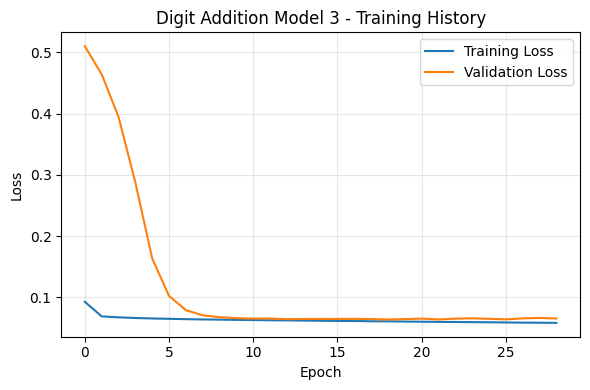

Digit Addition Model 3 Final Validation Loss: 0.065594
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


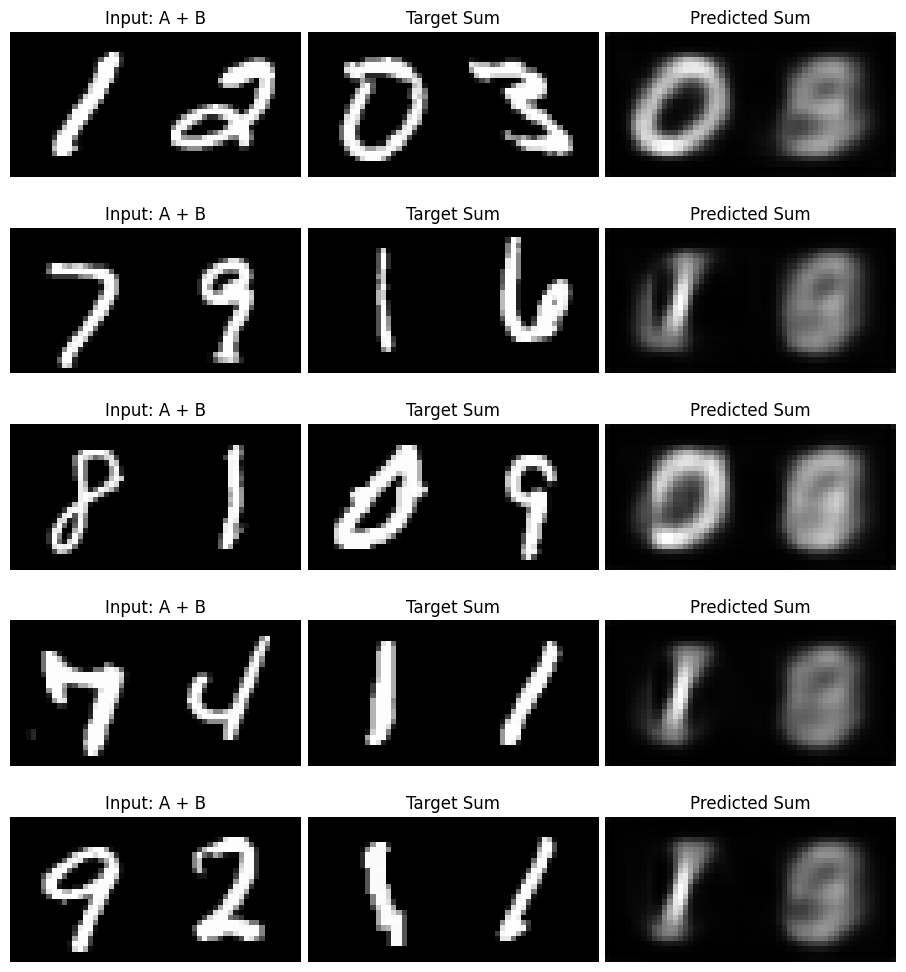

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Digit Addition Model 3 Test MSE: 0.063397


In [6]:
# Model 3: Convolutional architecture for digit addition

# Encoder
encoder_input = layers.Input(shape=(28, 56, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
latent = layers.MaxPooling2D((2, 2), padding='same')(x)

encoder_da3 = Model(encoder_input, latent, name='encoder_digit_adder3')

# Decoder
decoder_input = layers.Input(shape=(4, 7, 128))
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(decoder_input)
x = layers.BatchNormalization()(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.UpSampling2D((2, 2))(x)     # (32, 56, 32)

# Crop to match output size (28, 56, 1)
x = layers.Cropping2D(cropping=((2, 2), (0, 0)))(x)      # (28, 56, 32)

decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

decoder_da3 = Model(decoder_input, decoder_output, name='decoder_digit_adder3')

# Digit Addition Autoencoder
autoencoder_da3 = Model(encoder_input, decoder_da3(encoder_da3(encoder_input)), name='autoencoder_digit_adder3')
autoencoder_da3.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True)

# Train the model
print("\nTraining Digit Addition Model 3...")
start_time = time.time()
history_da3 = autoencoder_da3.fit(train_inputs_cnn, train_outputs_cnn, epochs=50, batch_size=128, 
                                  validation_split=0.2, callbacks=[early_stop], verbose=1)
train_time_da3 = time.time() - start_time
print(f"Digit Addition Model 3 Training time: {train_time_da3:.2f} seconds")
print(f"Digit Addition Model 3 Stopped at Epoch: {len(history_da3.history['loss'])}")

# Plot history
dp.plot_history(history_da3, 'Digit Addition Model 3')

# Store validation loss
val_loss_da3 = history_da3.history['val_loss'][-1]
print(f"Digit Addition Model 3 Final Validation Loss: {val_loss_da3:.6f}")

# Visualize predictions
predictions_da3 = autoencoder_da3.predict(test_inputs_cnn[::10])
da.plot_addition_examples(test_inputs_cnn[::10], test_outputs_cnn[::10], predictions_da3)

# Evaluate
mse_da3 = dp.calculate_mse(test_outputs_cnn, autoencoder_da3.predict(test_inputs_cnn))
print(f"Digit Addition Model 3 Test MSE: {mse_da3:.6f}")

#### **Model 4: U-Net Style Digit Adder Autoencoder**

Advanced architecture with skip connections and learning rate scheduler. 


Training Digit Addition Model 4 (U-Net) with Skip Connections...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 607ms/step - loss: 0.1589 - val_loss: 0.0974 - learning_rate: 5.0000e-04
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 605ms/step - loss: 0.0996 - val_loss: 0.1086 - learning_rate: 5.0000e-04
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 640ms/step - loss: 0.0829 - val_loss: 0.6095 - learning_rate: 5.0000e-04
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 669ms/step - loss: 0.0772 - val_loss: 0.4483 - learning_rate: 5.0000e-04
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 661ms/step - loss: 0.0751 - val_loss: 0.6260 - learning_rate: 5.0000e-04
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - loss: 0.0747
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 646ms/step - loss: 0.0744 - val_loss: 0.1746 - learning_rate: 5.0000e-04
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 651ms/step - loss: 0.0730 - val_loss: 0.1227 - learning_rate: 2.5000e-

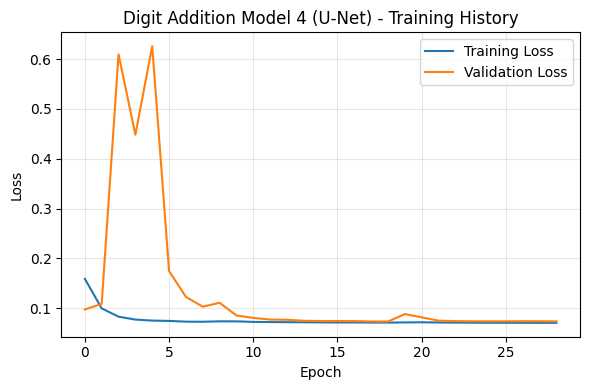


Digit Addition Model 4 Final Validation Loss: 0.073589
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


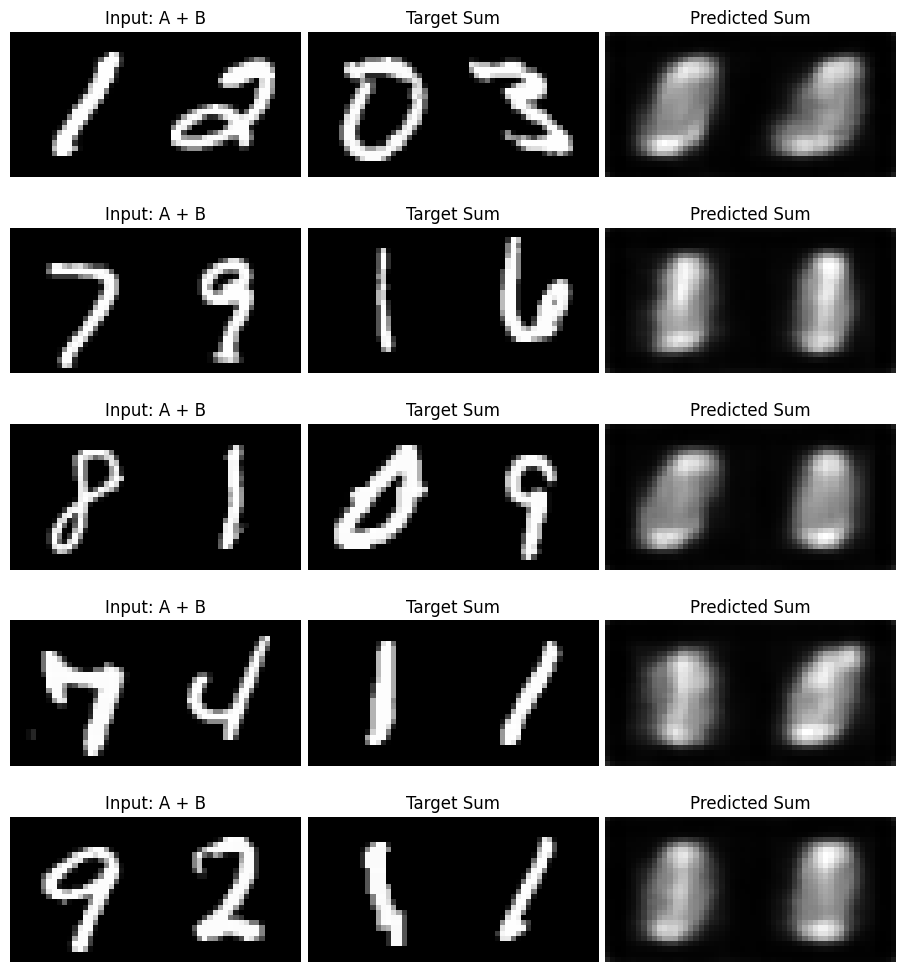

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step
Digit Addition Model 4 Test MSE: 0.073155


In [7]:
# Model 4: U-Net style architecture with Skip Connections for Digit Addition

# Encoder input
encoder_input = layers.Input(shape=(28, 56, 1))

# Encoder (Contracting Path)
x1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dropout(0.3)(x1)
x = layers.MaxPooling2D((2, 2), padding='same')(x1)

x2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
x = layers.MaxPooling2D((2, 2), padding='same')(x2)

x3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x3 = layers.BatchNormalization()(x3)
x3 = layers.Dropout(0.4)(x3)

# Decoder (Expansive Path with Skip Connections)
x = layers.UpSampling2D((2, 2))(x3)
skip1 = layers.Concatenate()([x, x2])    # Skip connection from encoder block 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(skip1)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.UpSampling2D((2, 2))(x)
skip2 = layers.Concatenate()([x, x1])    # Skip connection from encoder block 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(skip2)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# U-Net Autoencoder
autoencoder_da4 = Model(encoder_input, decoder_output, name='autoencoder_digit_adder4_UNet')

# Compile
autoencoder_da4.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train
print("\nTraining Digit Addition Model 4 (U-Net) with Skip Connections...")
start_time = time.time()
history_da4 = autoencoder_da4.fit(train_inputs_cnn, train_outputs_cnn, epochs=50, batch_size=128,
                                validation_split=0.2, callbacks=[early_stop, reduce_lr], verbose=1)
train_time_da4 = time.time() - start_time
print(f"\nDigit Addition Model 4 Training Time: {train_time_da4:.2f} seconds")
print(f"Digit Addition Model 4 Stopped at Epoch: {len(history_da4.history['loss'])}")

# Plot history
dp.plot_history(history_da4, "Digit Addition Model 4 (U-Net)")

# Store validation loss
val_loss_da4 = history_da4.history['val_loss'][-1]
print(f"\nDigit Addition Model 4 Final Validation Loss: {val_loss_da4:.6f}")

# Visualize predictions
predictions_da4 = autoencoder_da4.predict(test_inputs_cnn[::10])
da.plot_addition_examples(test_inputs_cnn[::10], test_outputs_cnn[::10], predictions_da4)

# Evaluate
mse_da4 = dp.calculate_mse(test_outputs_cnn, autoencoder_da4.predict(test_inputs_cnn))
print(f"Digit Addition Model 4 Test MSE: {mse_da4:.6f}")


#### **Model Comparison Summary**
Compare all models.

MODEL COMPARISON
Model                               MSE          Encoding     Parameters      Training Time  
----------------------------------------------------------------------------------------------------
Model 1: Dense AE                   0.066641     256          4,526,880       88.11          
Model 2: Deep Dense AE              0.059476     512          11,673,632      177.88         
Model 3: Conv AE                    0.063397     3584         334,593         649.30         
Model 4: U-Net AE                   0.073155     12544        232,577         1204.55        



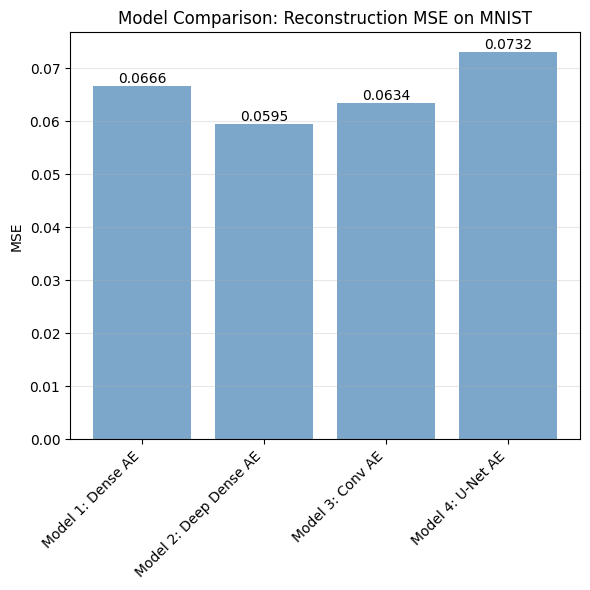

In [9]:
# Collect all digit addition results
results_da = [
    ("Model 1: Dense AE", mse_da1, 256, autoencoder_da1.count_params(), train_time_da1),
    ("Model 2: Deep Dense AE", mse_da2, 512, autoencoder_da2.count_params(), train_time_da2),
    ("Model 3: Conv AE", mse_da3, 4*7*128, autoencoder_da3.count_params(), train_time_da3),
    ("Model 4: U-Net AE", mse_da4, 7*14*128, autoencoder_da4.count_params(), train_time_da4)
]

# Print comparison table
dp.compare_models_table(results_da)

# Visualize MSE comparison
model_names = [r[0] for r in results_da]
mse_values = [r[1] for r in results_da]

plt.figure(figsize=(6, 6))
bars = plt.bar(range(len(model_names)), mse_values, color='steelblue', alpha=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylabel('MSE')
plt.title('Model Comparison: Reconstruction MSE on MNIST')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{mse_values[i]:.4f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()